# Machine Learning Assignment (Semester 252)

In [1]:
import os

# Repo information
GIT_REPO = "ML-Assignment"
GIT_PATH = f"https://github.com/phngan05/ML-Assignment.git"

# Check if the repository already exists, if not clone it. If it exists, pull the latest changes.
%cd /content
if not os.path.exists(GIT_REPO):
    !git clone {GIT_PATH}
    %cd {GIT_REPO}
else:
    %cd {GIT_REPO}
    !git pull origin main


/content
Cloning into 'ML-Assignment'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 78 (delta 29), reused 61 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 11.58 MiB | 18.50 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/ML-Assignment


In [2]:
!pip install -r requirements.txt --quiet

In [3]:
# Download the dataset
from modules import utils
utils.setup_data("blessondensil294/topic-modeling-for-research-articles")

--- Setting up Kaggle API and downloading data... ---
--- Data downloaded successfully into 'data' ---


In [4]:
# Use for check /content directory structure in VSCode
!ls -R /content

/content:
ML-Assignment  sample_data

/content/ML-Assignment:
data  modules  notebooks  README.md  requirements.txt

/content/ML-Assignment/data:
test.csv  train.csv

/content/ML-Assignment/modules:
eda.py	evaluation.py  model.py  preprocessing.py  __pycache__	utils.py

/content/ML-Assignment/modules/__pycache__:
utils.cpython-312.pyc

/content/ML-Assignment/notebooks:
main.ipynb

/content/sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [5]:
!cat /content/ML-Assignment/modules/eda.py

import numpy as np
from nltk.tokenize import sent_tokenize
import matplotlib.pyplot as plt
import seaborn as sns


def calculate_text_lengths(df, column_name):
    """
    Calculates the necessary lengths in a specified text column.
    """
    # Calculate the number of characters (including spaces)
    df[f'{column_name}_chars'] = df[column_name].str.len()
    
    # Calculate the number of words (split by spaces)
    df[f'{column_name}_words'] = df[column_name].apply(lambda x: len(str(x).split()))
    
    # Calculate the mean word length
    df[f'{column_name}_mean_word_length'] = df[f'{column_name}_chars'] / df[f'{column_name}_words']
    
    # Calculate mean sentence length
    df[f'{column_name}_mean_sentence_length'] = df[column_name].map(lambda x: np.mean([len(sent) for sent in sent_tokenize(str(x))]))
    
    return df

def visualize_text_length_distribution(df, column_name):
    """
    Visualize the distribution of text lengths using boxplot and histogram.
    """
    fig,

In [6]:
import pandas as pd
df = pd.read_csv("/content/ML-Assignment/data/train.csv")
df.head()

,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0,0


## Exploratory Data Analysis

### Statistics & General Analysis

In [7]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    20972 non-null  int64 
 1   TITLE                 20972 non-null  object
 2   ABSTRACT              20972 non-null  object
 3   Computer Science      20972 non-null  int64 
 4   Physics               20972 non-null  int64 
 5   Mathematics           20972 non-null  int64 
 6   Statistics            20972 non-null  int64 
 7   Quantitative Biology  20972 non-null  int64 
 8   Quantitative Finance  20972 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 1.4+ MB


(20972, 9)

In [8]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [9]:
label_columns = [
    "Computer Science",
    "Physics",
    "Mathematics",
    "Statistics",
    "Quantitative Biology",
    "Quantitative Finance"
]
df[label_columns].sum()

,0
Computer Science,8594
Physics,6013
Mathematics,5618
Statistics,5206
Quantitative Biology,587
Quantitative Finance,249


### Class Distribution Analysis

### Length Analysis

In [10]:
import nltk
from modules.eda import calculate_text_lengths
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')
    
calculate_text_lengths(df, 'TITLE')
calculate_text_lengths(df, 'ABSTRACT')

df.info()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             20972 non-null  int64  
 1   TITLE                          20972 non-null  object 
 2   ABSTRACT                       20972 non-null  object 
 3   Computer Science               20972 non-null  int64  
 4   Physics                        20972 non-null  int64  
 5   Mathematics                    20972 non-null  int64  
 6   Statistics                     20972 non-null  int64  
 7   Quantitative Biology           20972 non-null  int64  
 8   Quantitative Finance           20972 non-null  int64  
 9   TITLE_chars                    20972 non-null  int64  
 10  TITLE_words                    20972 non-null  int64  
 11  TITLE_mean_word_length         20972 non-null  float64
 12  TITLE_mean_sentence_length     20972 non-null 

In [11]:
title_length_columns = ['TITLE_chars', 'TITLE_words', 'TITLE_mean_word_length', 'TITLE_mean_sentence_length']
abstract_length_columns = ['ABSTRACT_chars', 'ABSTRACT_words', 'ABSTRACT_mean_word_length', 'ABSTRACT_mean_sentence_length' ]

#### Title Analysis

In [12]:
df[title_length_columns].describe()

,TITLE_chars,TITLE_words,TITLE_mean_word_length,TITLE_mean_sentence_length
count,20972.000000,20972.000000,20972.000000,20972.000000
mean,72.897721,9.514972,7.812645,72.235310
std,26.128903,3.611493,1.246562,25.959505
min,7.000000,1.000000,3.500000,7.000000
25%,54.000000,7.000000,7.000000,54.000000
50%,71.000000,9.000000,7.714286,70.000000
75%,88.000000,12.000000,8.545455,88.000000
max,239.000000,40.000000,17.500000,239.000000


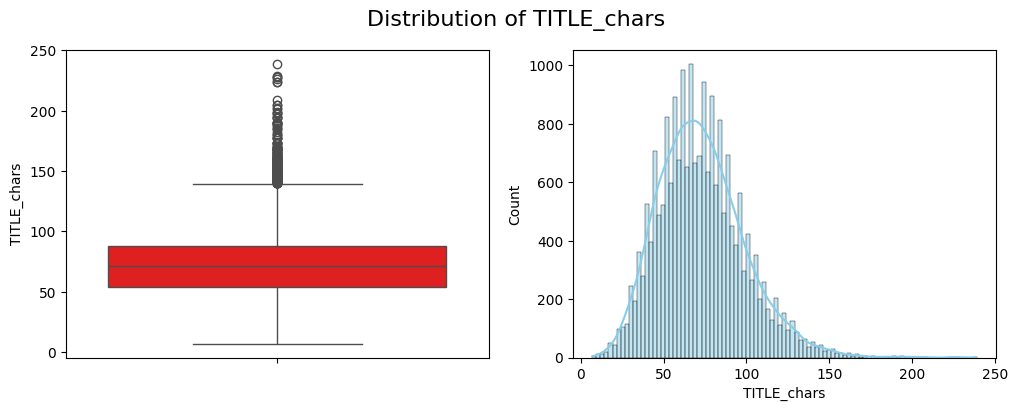

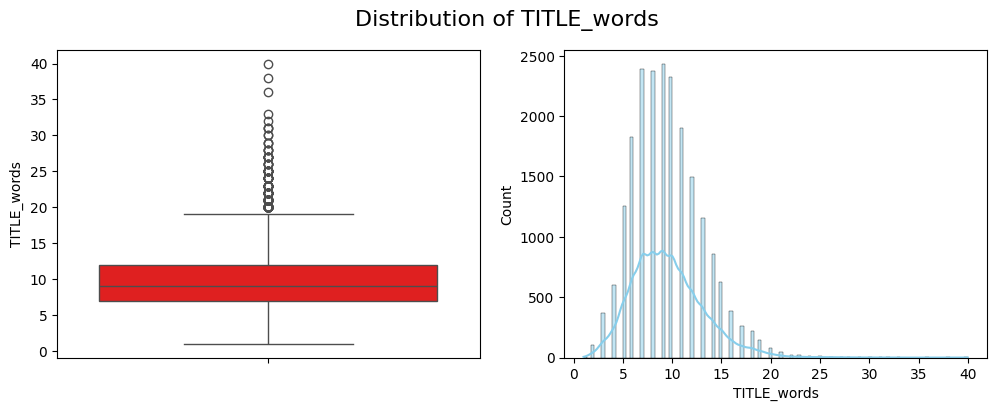

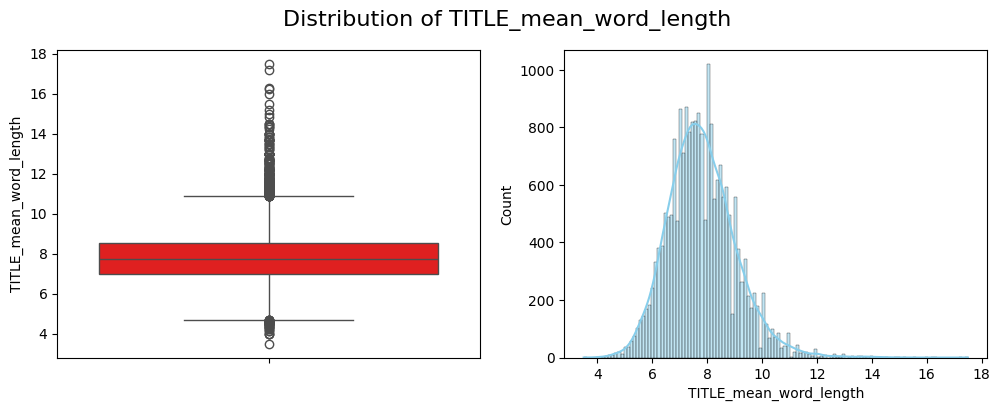

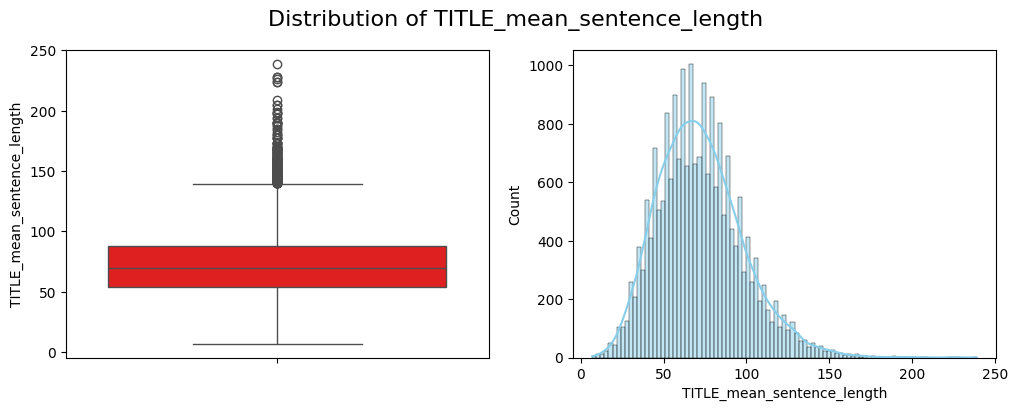

In [13]:
from modules.eda import visualize_text_length_distribution
for col in title_length_columns:
    visualize_text_length_distribution(df, col)

Titles are generally short and concise, with an average length of ~73 characters (~9–10 words). Most titles fall within 50–90 characters or 7–12 words, showing a relatively consistent structure. The distributions are slightly right-skewed, with several upper outliers representing unusually long or descriptive titles. The average word length (~7–8 characters) suggests the frequent use of technical or academic vocabulary.

#### Abstract Analysis

In [14]:
df[abstract_length_columns].describe()

,ABSTRACT_chars,ABSTRACT_words,ABSTRACT_mean_word_length,ABSTRACT_mean_sentence_length
count,20972.000000,20972.000000,20972.000000,20972.000000
mean,1009.103376,148.404873,6.821117,164.264092
std,408.641363,60.781306,0.466272,46.169121
min,7.000000,1.000000,4.052239,6.000000
25%,714.000000,104.000000,6.532609,137.000000
50%,989.000000,145.000000,6.806857,158.250000
75%,1290.000000,190.000000,7.090332,184.250000
max,2761.000000,449.000000,19.270270,1324.000000


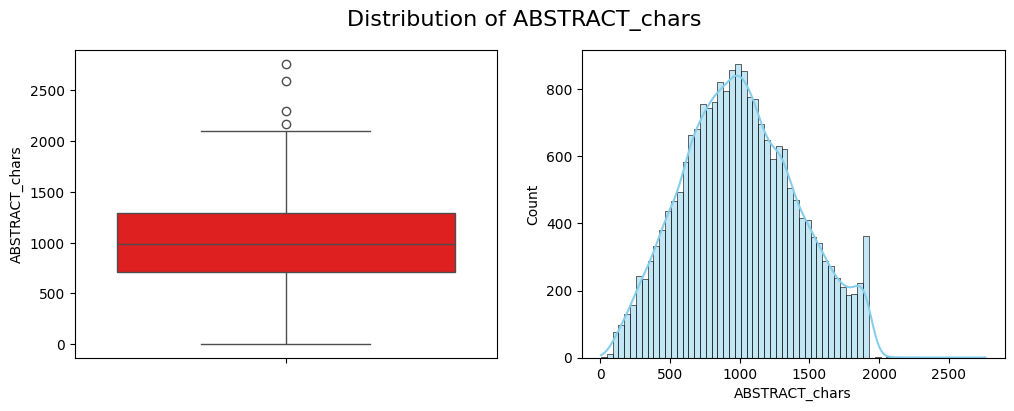

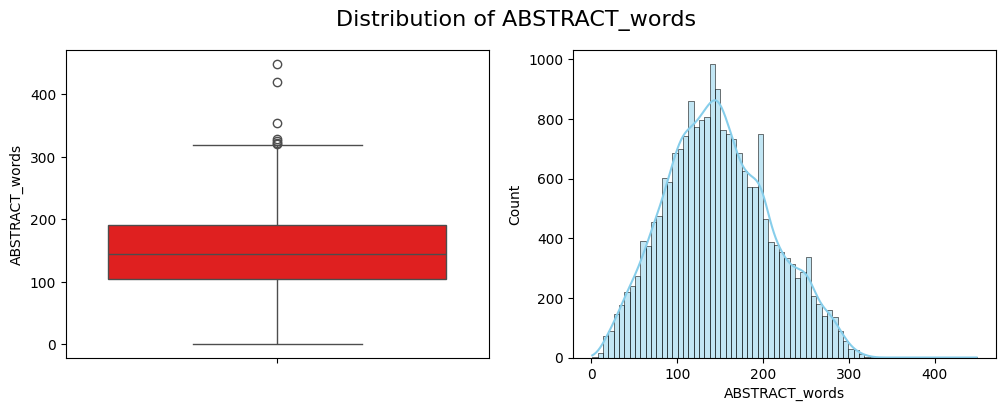

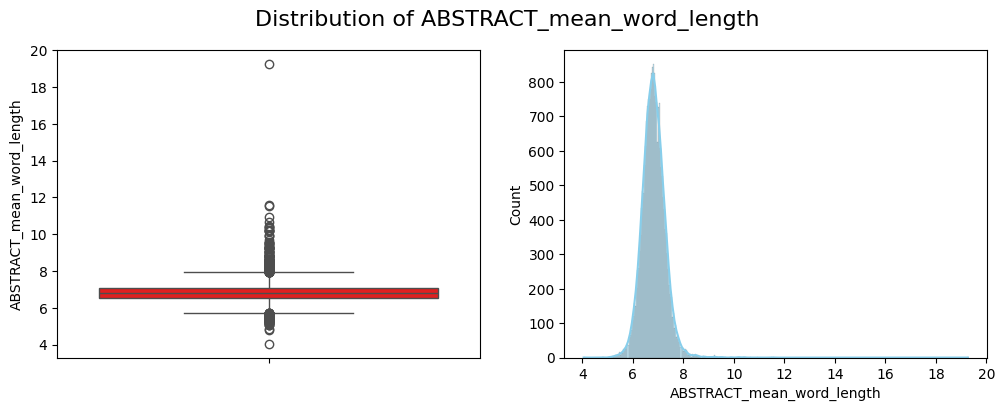

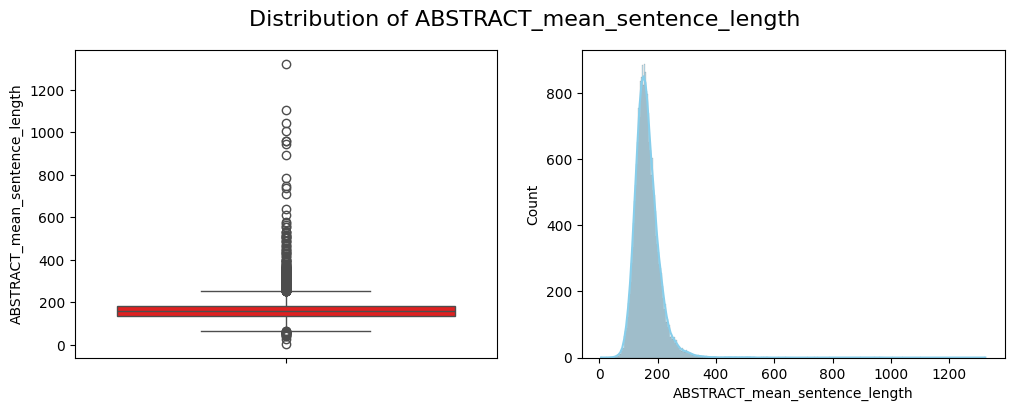

In [15]:
for col in abstract_length_columns:
    visualize_text_length_distribution(df, col)

Abstracts are significantly longer and more variable than titles, averaging ~1000 characters (~148 words). Most abstracts fall between 500–1500 characters or 100–200 words, which aligns with typical academic writing conventions. Sentence lengths are mostly concentrated around 100–200 characters, though some extreme outliers indicate either highly complex sentences or formatting inconsistencies. The average word length (~6–7 characters) also reflects the use of technical terminology.